
# Exploratory Data Analysis (EDA) 
Fields of The World (FTW) - Austria


In [1]:
import importlib
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import eda_utils
importlib.reload(eda_utils)

from eda_utils import (
    SPLIT_COLORS,
    WINDOW_COLORS,
    build_grid_chips_map,
    collect_gfm_features,
    common_chip_ids,
    feat_pca_plot,
    fit_pca,
    list_stems,
    plot_chip_samples,
    report_dataset_stats,
)

c:\Users\redone-pc\Desktop\ftw-baselines\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# shared dataset paths and metadata for Austria
country = 'austria'
data_dir = Path(f'../data/ftw/{country}')

modality_dirs = {
    'window_a': data_dir / 's2_images' / 'window_a',
    'window_b': data_dir / 's2_images' / 'window_b',
    'instance': data_dir / 'label_masks' / 'instance',
    'semantic_2class': data_dir / 'label_masks' / 'semantic_2class',
    'semantic_3class': data_dir / 'label_masks' / 'semantic_3class',
}

with open(data_dir / f'data_config_{country}.json') as f:
    data_config = json.load(f)

df_chips = pd.read_parquet(data_dir / f'chips_{country}.parquet')
common_ids = common_chip_ids(df_chips, modality_dirs)
print(f'{len(data_config.get("grids", []))} grids, {len(df_chips):,} chips in parquet, '
      f'{len(common_ids):,} complete across all modalities.')

7 grids, 6,686 chips in parquet, 6,685 complete across all modalities.


In [3]:
m_combined = build_grid_chips_map(
    data_config, df_chips, output_path=Path('./outputs/grid_chips_map.html')
)
m_combined

## Example Data
The code cell below visualizes randomly sampled chips from the Austria dataset.

Each row corresponds to one chip ID, and the five columns show:
1. `window_a` image (captured between 2021-04-01 and 2021-07-15)
2. `window_b` image (captured between 2021-07-16 and 2021-11-01)
3. Instance mask (`label_masks/instance`)
4. Semantic 2-class mask (`label_masks/semantic_2class`)
5. Semantic 3-class mask (`label_masks/semantic_3class`)

Only chip IDs available in all five folders are sampled, so every row is complete.

Visualizing 6 random chips.


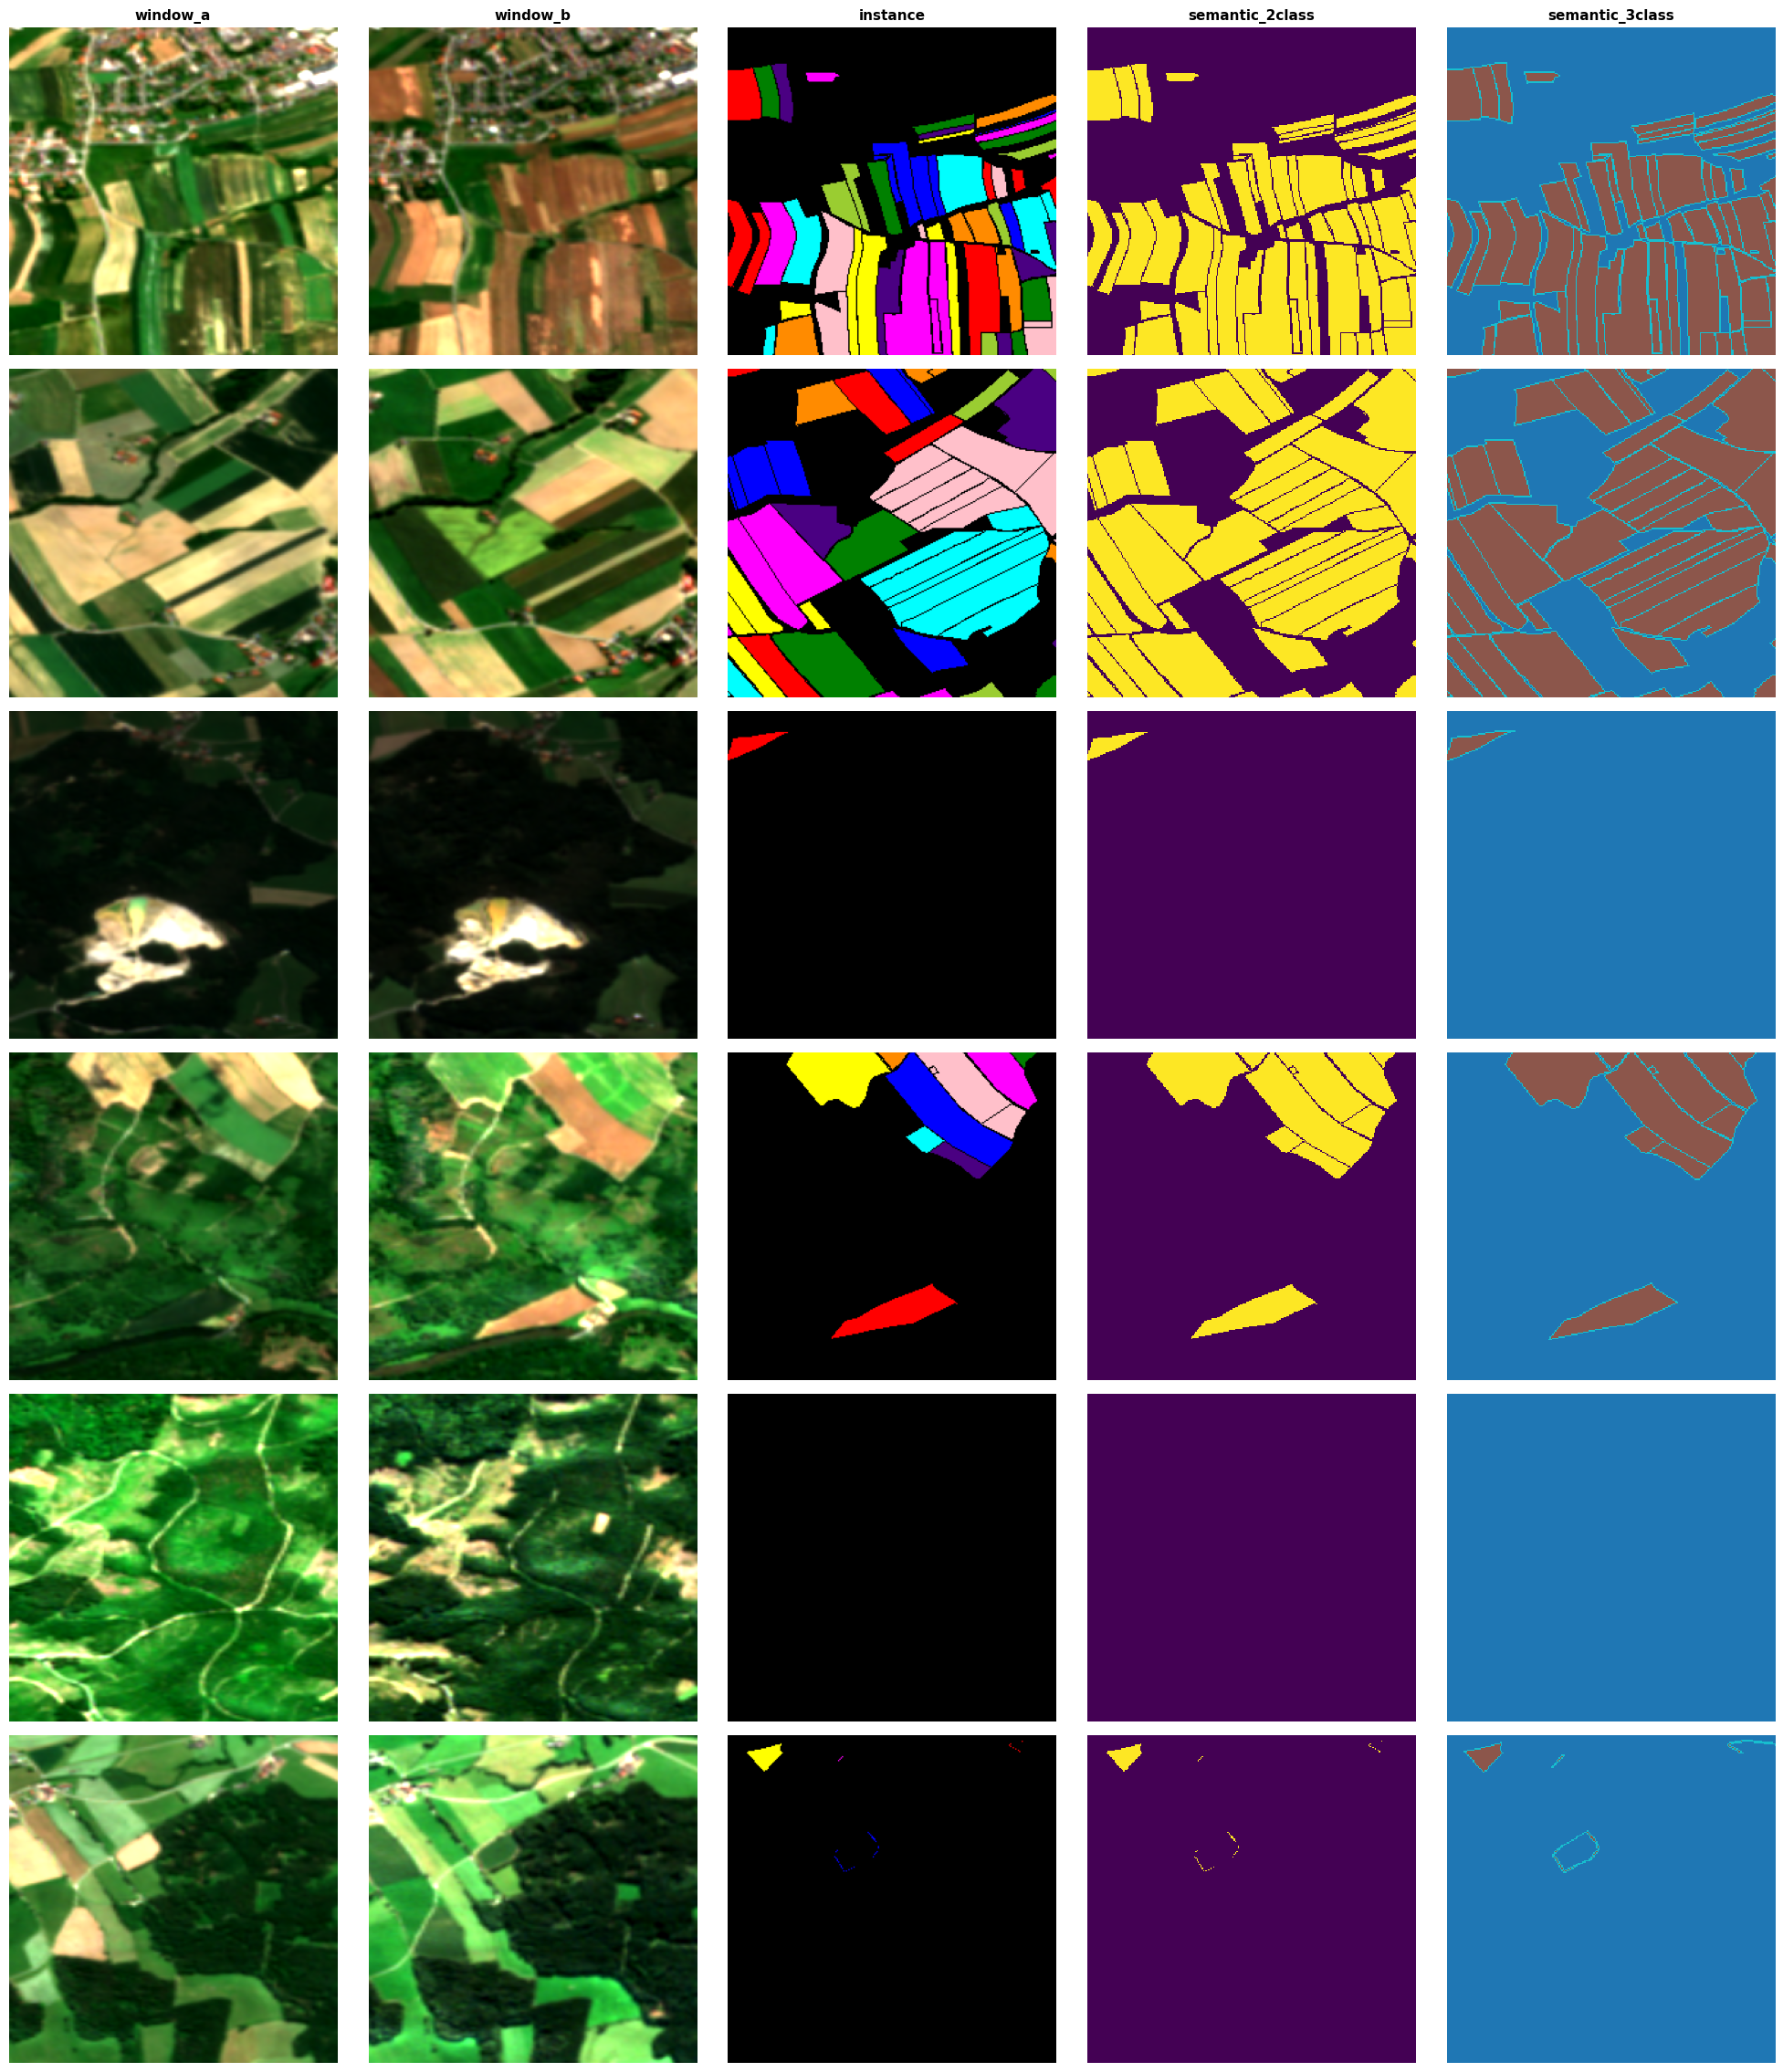

In [4]:
if not common_ids:
    raise RuntimeError('No common chip IDs found across all required folders.')

sample_ids = random.Random(42).sample(sorted(common_ids), k=min(6, len(common_ids)))
print(f'Visualizing {len(sample_ids)} random chips.')
plot_chip_samples(sample_ids, modality_dirs)
plt.show()

## Report dataset statistics

FTW Austria Dataset Summary
Grids in config                    : 7
Total chips in parquet             : 6,686
Complete chips (all modalities)    : 6,685

Split counts (complete chips):
  - train: 5,303
  - val  : 637
  - test : 745

Total field instances in labels    : 209,804
Average field size                 : 535.85 pixels
Median field size                  : 298.00 pixels
Max field size                     : 27,912 pixels
Min field size                     : 1 pixels
Field-to-total area ratio          : 0.2566 (25.66%)
Average of fields per chip         : 31.38*
*: This makes a dense object segmentation task.
Removing outliers outside [1.00, 7209.39] pixels for histogram.
0 small and 210 large fields removed.


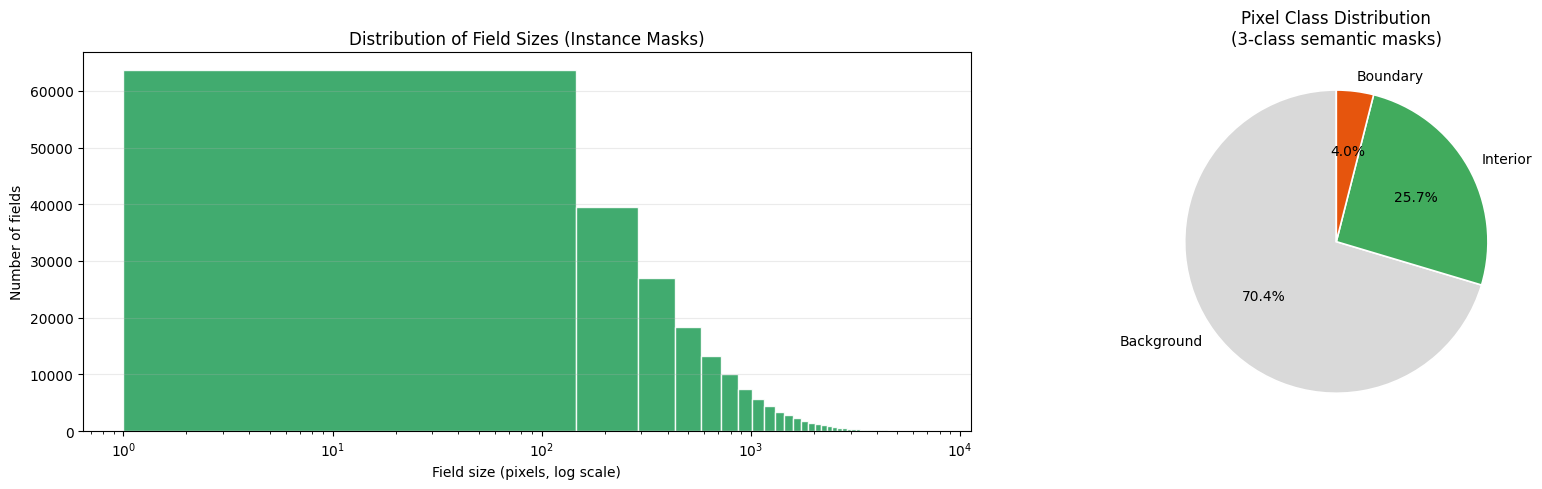

In [5]:
# Report dataset statistics
report_dataset_stats(data_config, df_chips, modality_dirs, common_ids=common_ids)

## Principal Component Analysis (PCA)

Use Features extracted from the FTW-Austria dataset using Geospatial Foundation Models (GFM).

Selected GFM: CLAY. Features downloaded from Source Cooperative: [CLAY features for FTW](https://source.coop/mvrl/ftw-inference-gfm/precomputed_feats/clay/austria) 

In [6]:
# PCA setup: discover chips that have BOTH window embeddings on disk AND a parquet row.
# Set n_pca_samples to an integer for fast dev iteration; None uses all available chips.
# n_pca_samples = 200
n_pca_samples = None

gfm_feats_dir = data_dir / 'precomputed_feats_clay'
gfm_window_dirs = {
    'window_a': gfm_feats_dir / 'window_a',
    'window_b': gfm_feats_dir / 'window_b',
}

parquet_ids = set(df_chips['aoi_id'])
ids_by_window = {w: list_stems(d, suffix='.npz', strip_prefix='clay_') for w, d in gfm_window_dirs.items()}
all_available_ids = sorted(parquet_ids.intersection(*ids_by_window.values()))

if n_pca_samples is not None and n_pca_samples < len(all_available_ids):
    available_ids = random.Random(0).sample(all_available_ids, k=n_pca_samples)
else:
    available_ids = all_available_ids

print(f'Feature root               : {gfm_feats_dir.resolve()}')
print(f'Chips in parquet           : {len(parquet_ids):,}')
for w, ids in ids_by_window.items():
    print(f'GFM files in {w:<11}: {len(ids):,}')
print(f'All usable chips           : {len(all_available_ids):,}')
print(f'Chips for this PCA run     : {len(available_ids):,}'
      + (f'  (sampled, set n_pca_samples=None for full run)' if n_pca_samples else ''))

Feature root               : C:\Users\redone-pc\Desktop\ftw-baselines\data\ftw\austria\precomputed_feats_clay
Chips in parquet           : 6,686
GFM files in window_a   : 6,685
GFM files in window_b   : 6,686
All usable chips           : 6,685
Chips for this PCA run     : 6,685


In [7]:
X, attrs = collect_gfm_features(
    available_ids, gfm_window_dirs, modality_dirs['instance'], df_chips,
)
splits = attrs['split']
grid_name = attrs['grid_name']
n_fields = attrs['n_fields']
mean_field_size = attrs['mean_field_size']
total_field_size = attrs['total_field_size']
has_field = attrs['has_field']

if X.size:
    print(f'Feature matrix: shape={X.shape}, dtype={X.dtype}')
    print(f'Splits: {dict(pd.Series(splits).value_counts())}')
    print(f'Grids:  {dict(pd.Series(grid_name).value_counts())}')
    print(f'Chips with fields: {has_field.sum()} / {len(has_field)}')

Loading GFM features: 100%|██████████| 6685/6685 [07:40<00:00, 14.51it/s]

Feature matrix: shape=(6685, 2048), dtype=float32
Splits: {'train': np.int64(5303), 'test': np.int64(745), 'val': np.int64(637)}
Grids:  {'g94': np.int64(961), 'g95': np.int64(961), 'g83': np.int64(956), 'g79': np.int64(954), 'g82': np.int64(953), 'g77': np.int64(950), 'g78': np.int64(950)}
Chips with fields: 5446 / 6685


Explained variance ratio: PC1=0.6008, PC2=0.1169, sum=0.7177


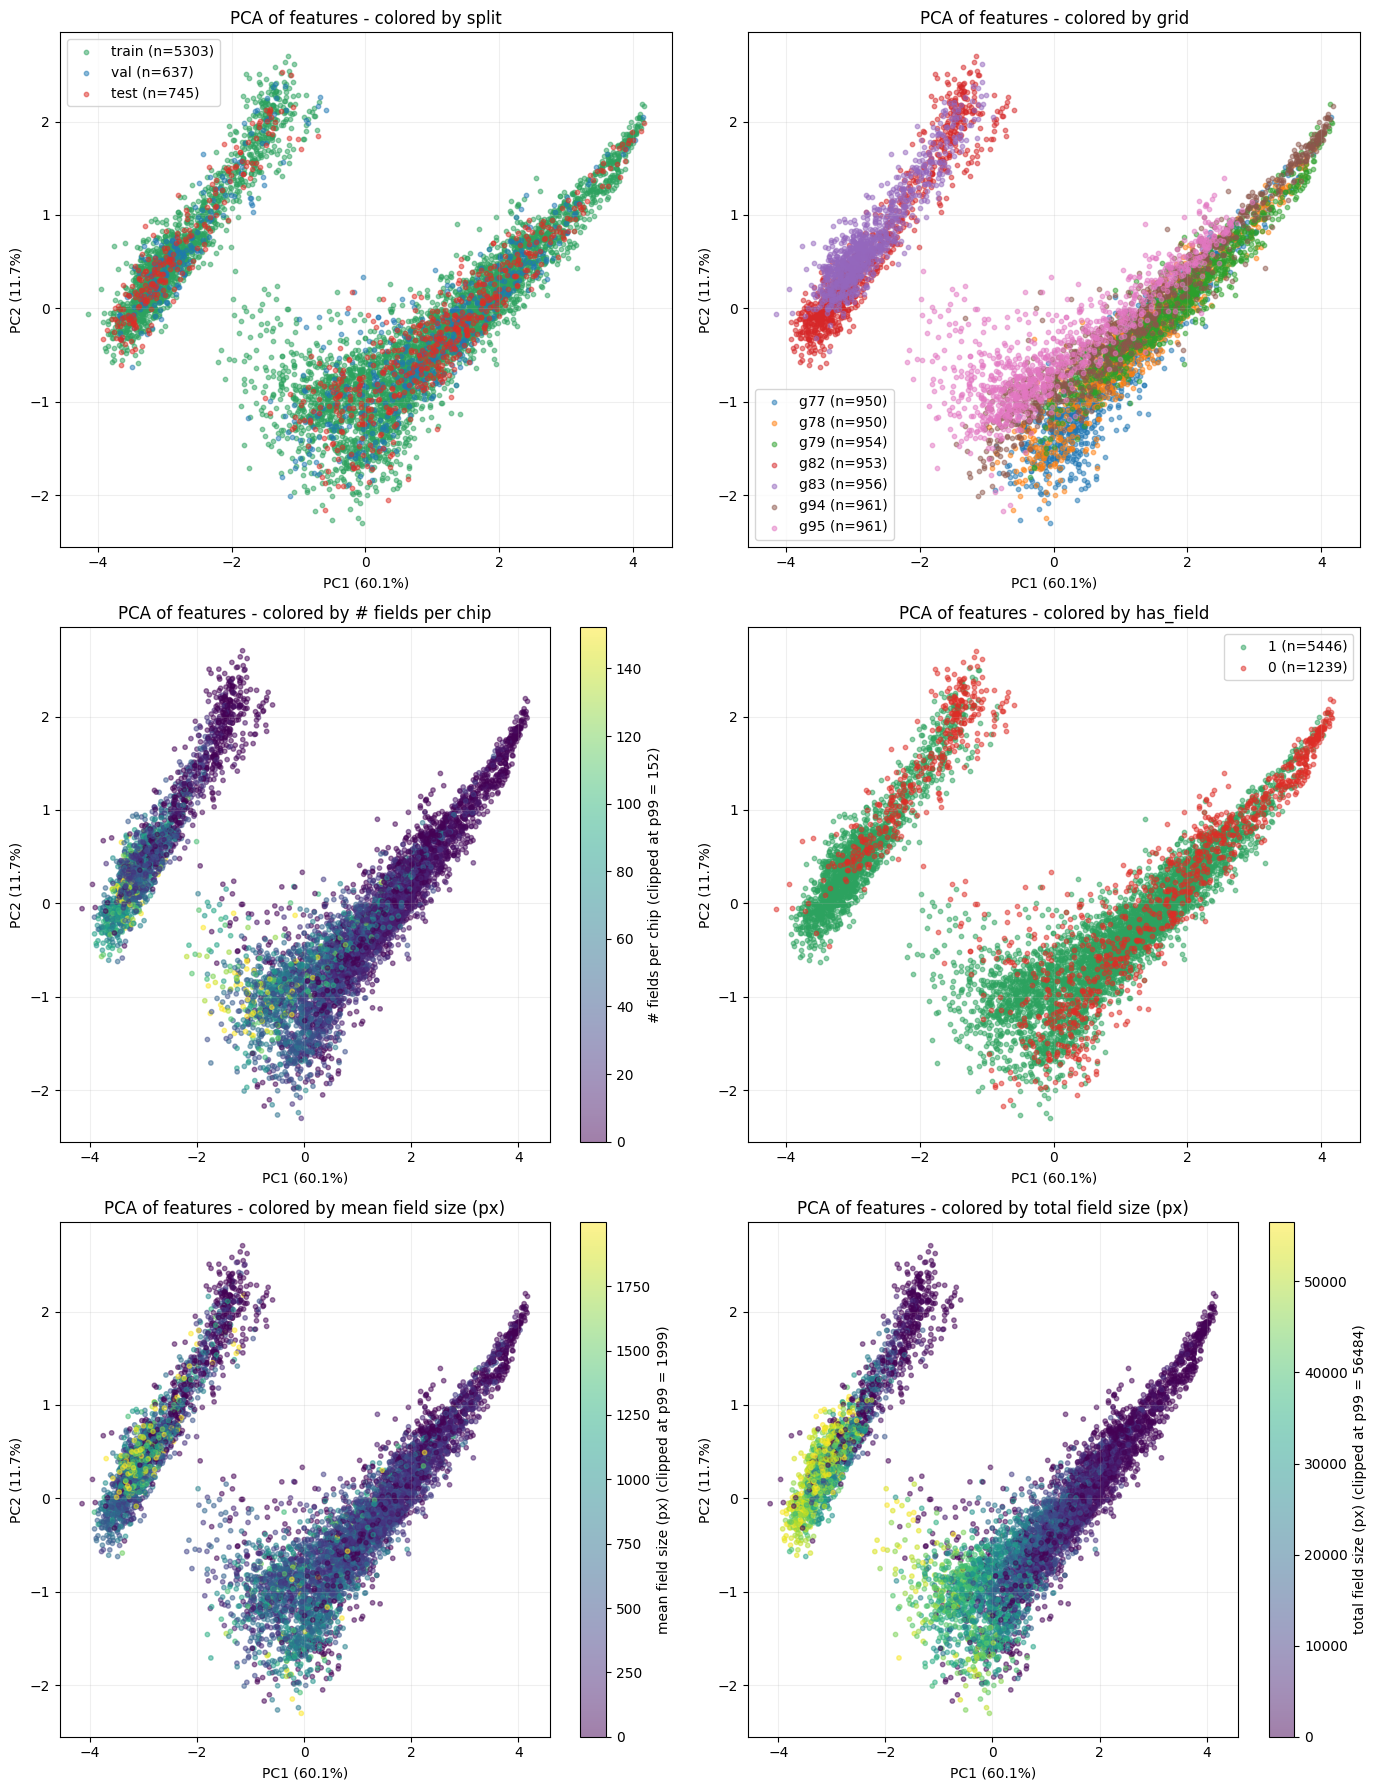

In [8]:
# PCA on concat(window_a, window_b) features. 3×2 grid: six chip-level attributes.
if X.size == 0:
    print('Skipping PCA: no feature rows yet.')
else:
    pca, Z = fit_pca(X)
    evr = pca.explained_variance_ratio_
    print(f'Explained variance ratio: PC1={evr[0]:.4f}, PC2={evr[1]:.4f}, sum={evr.sum():.4f}')

    fig, axes = plt.subplots(3, 2, figsize=(14, 18))
    feat_pca_plot(Z, evr, splits,
                  attr_name='split', palette=SPLIT_COLORS, ax=axes[0, 0])
    feat_pca_plot(Z, evr, grid_name,
                  attr_name='grid', ax=axes[0, 1])
    feat_pca_plot(Z, evr, n_fields,
                  attr_name='# fields per chip', vmax_percentile=99, ax=axes[1, 0])
    feat_pca_plot(Z, evr, has_field.astype(np.uint8),
                  attr_name='has field',
                  palette={1: '#2ca25f', 0: '#de2d26'},
                  title='PCA of features - colored by has_field',
                  ax=axes[1, 1])
    feat_pca_plot(Z, evr, mean_field_size,
                  attr_name='mean field size (px)', vmax_percentile=99, ax=axes[2, 0])
    feat_pca_plot(Z, evr, total_field_size,
                  attr_name='total field size (px)', vmax_percentile=99, ax=axes[2, 1])
    plt.tight_layout()
    plt.show()



**Reading the plots**

* *Top-left (split):* the heavy overlap between train/val/test confirms the splits are well-mixed in feature space. There’s no obvious separation or clustering by split, which suggests minimal distribution shift and low risk of leakage driven by spatial or temporal grouping.

* *Top-right (grid):* distinct color groupings align with the two main “arms” of the PCA shape, indicating that grid IDs are not uniformly distributed across feature space. Some grids dominate specific regions, suggesting latent spatial structure or acquisition conditions are encoded in the features.

* *Middle-left (# fields per chip):* a smooth color gradient appears along the lower arm (especially near the center), meaning field count is partially aligned with the principal components. Higher densities cluster in a specific subregion, implying this variable is a strong contributor to variance captured by PCA.

* *Middle-right (has_field):* the binary labels are mostly mixed, but with mild regional bias—certain areas (e.g., the right arm) lean more toward “has_field = 1.” This suggests the representation separates some field presence signal, though not cleanly.

* *Bottom-left (mean field size):* a gradient is visible, especially along the left arm, indicating that mean field size correlates with the embedding. Larger fields tend to occupy a more localized region, implying this feature is encoded but not dominant globally.

* *Bottom-right (total field size):* the clearest structure among the continuous variables—strong gradients appear, especially on the left cluster. This suggests total field size is one of the primary drivers of variation in the learned features, heavily influencing PC1/PC2 positioning.

**Overall takeaway**

The PCA space shows a structured, non-random geometry where key physical attributes (field count, size, total area) are partially disentangled along dominant axes. Splits are well-balanced, but grid-level clustering indicates underlying spatial correlations that could matter for generalization.


### PCA plot splitting window a & b

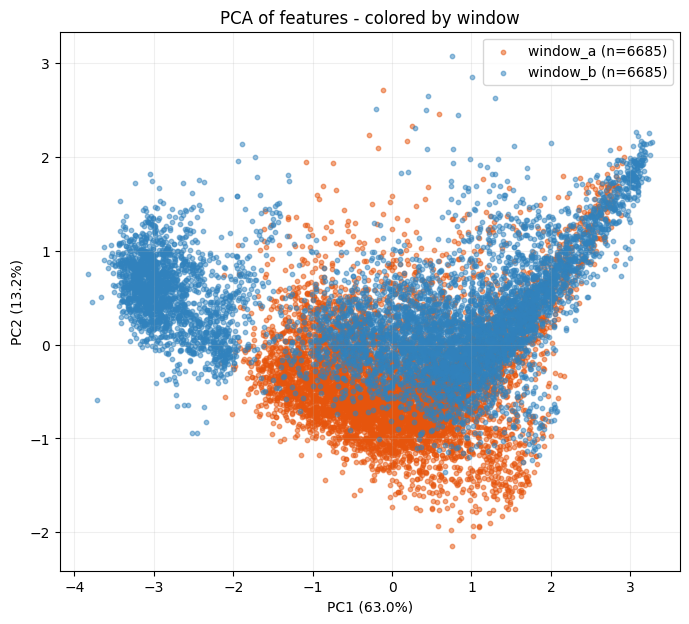

In [9]:
# Each chip -> 2 points (one per window); shows temporal drift in Clay feature space.
if X.size == 0:
    print('Skipping per-window PCA: no feature rows yet.')
else:
    half = X.shape[1] // 2
    X_ab = np.concatenate([X[:, :half], X[:, half:]], axis=0)
    window_labels = np.array(['window_a'] * X.shape[0] + ['window_b'] * X.shape[0])
    pca_w, Z_w = fit_pca(X_ab)
    feat_pca_plot(Z_w, pca_w.explained_variance_ratio_, window_labels,
                  attr_name='window', palette=WINDOW_COLORS)
    plt.show()